<style>
    :root {
        --accent: #38bdf8;
        --bg-dark: #0f172a;
    }
    .jp-Notebook { background-color: var(--bg-dark) !important; color: #e2e8f0 !important; }
    .jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2 { color: var(--accent) !important; border-bottom: 1px solid rgba(56, 189, 248, 0.2) !important; }
    .insight-card {
        background: rgba(56, 189, 248, 0.05);
        border-left: 4px solid var(--accent);
        padding: 1.2rem;
        border-radius: 8px;
        margin: 1rem 0;
    }
    .status-tag {
        background: var(--accent);
        color: var(--bg-dark);
        padding: 2px 8px;
        border-radius: 4px;
        font-weight: bold;
        font-size: 0.8em;
    }
</style>

# 🔬 Intel Core Ultra NPU: Unified GNN Benchmarking Suite

<span class="status-tag">ADVANCED ANALYTICS MODE</span>

This notebook provides a complete research pipeline with time-synchronized energy correlation for each model architecture.

In [11]:
import os, sys, json, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown, HTML

RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
FIGURES_DIR = Path("paper/figures")

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
print("✅ Advanced Analytics Ready.")

✅ Advanced Analytics Ready.


### 📦 Step 1: Model Suite Generation
GNN + baseline (CNN/NLP) models; standardized and quantized.

In [12]:
!python analysis/model_prep.py

Exporting GCN to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\models\GCN_fp32.onnx...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Done.
GCN_int8.onnx already exists, skipping quantization.
Exporting GraphSAGE to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\models\GraphSAGE_fp32.onnx...
[torch.onnx] Obtain model graph for `GraphSAGE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphSAGE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translat

W0501 17:33:34.320000 16428 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0501 17:33:34.325000 16428 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0501 17:33:34.325000 16428 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
c:\Users\yusuf\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W0501 17:33:37.345000 16428 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0501 17:33:37.347000 16428 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi

### 📈 Step 2: Scalability & Timing Study
Executing models while recording high-precision start/end timestamps for energy correlation.

In [13]:
!python analysis/scalability_analyzer.py --iterations 100 --repeats 3

Processing model: APPNP_fp32.onnx
Processing model: APPNP_int8.onnx
Processing model: GAT_fp32.onnx
Processing model: GAT_int8.onnx
Processing model: GCN_fp32.onnx
Processing model: GCN_int8.onnx
Processing model: GIN_fp32.onnx
Processing model: GIN_int8.onnx
Processing model: GraphSAGE_fp32.onnx
Processing model: GraphSAGE_int8.onnx
Processing model: GraphTransformer_fp32.onnx
Processing model: GraphTransformer_int8.onnx
Processing model: mobilenetv2_fp32.onnx
Processing model: mobilenetv2_int8.onnx
  -> Skipping model mobilenetv2_int8.onnx due to error: [ONNXRuntimeError] : 1 : FAIL : This is an invalid model. Error: the graph is not acyclic.
Processing model: resnet50_fp32.onnx
Processing model: resnet50_int8.onnx
  -> Skipping model resnet50_int8.onnx due to error: [ONNXRuntimeError] : 1 : FAIL : This is an invalid model. Error: the graph is not acyclic.
Processing model: SGC_fp32.onnx
Processing model: SGC_int8.onnx
  -> Exported profiling trace for [SGC_int8] (Baseline) to result

### 🔍 Step 3: Operator Profiling
Deep-dive into graph fusion and bottleneck identification.

In [14]:
!python analysis/profiling_analyzer.py


RESEARCH METRICS SUMMARY
----------------------------------------
Fusion Gain Ratio (FGR): 0.9743
Compilation Efficiency Index (CEI): 0.0000
NPU Support Ratio (Optimized): 33.1%
Baseline Latency: 148.50 ms
Optimized Latency: 152.42 ms
Latency Reduction: 0.00 ms

Detailed analysis saved to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results


### 💻 Step 4: Hardware Comparison
Benchmarking all models across CPU, GPU, and NPU.

In [ ]:
import glob
from pathlib import Path

# Choose mode: "quick" or "full"
RUN_MODE = "full"

EXPECTED_MODELS = {
    "appnp_fp32.onnx",
    "gat_fp32.onnx",
    "gcn_fp32.onnx",
    "gin_fp32.onnx",
    "graphsage_fp32.onnx",
    "graphtransformer_fp32.onnx",
    "sgc_fp32.onnx",
    "resnet50_fp32.onnx",
    "mobilenetv2_fp32.onnx",
    "bert-tiny_fp32.onnx",
}

if RUN_MODE == "quick":
    iterations = 10
    repeats = 1
    allowlist = {
        "gcn_fp32.onnx",
        "graphsage_fp32.onnx",
        "resnet50_fp32.onnx",
    }
else:
    # Use these as defaults; increase for paper-grade numbers
    iterations = 30
    repeats = 1
    allowlist = EXPECTED_MODELS

model_paths = [Path(p) for p in sorted(glob.glob("models/*_fp32.onnx"))]
found = {p.name.lower() for p in model_paths}
missing = sorted(name for name in (allowlist or set()) if name not in found)
if missing:
    print(f"⚠️ Missing models: {', '.join(missing)}")
for model_path in model_paths:
    if allowlist and model_path.name.lower() not in allowlist:
        continue
    print(f"🚀 Device Comparison: {model_path}")
    !python analysis/hw_comparison.py --model {model_path} --iterations {iterations} --repeats {repeats}

⚠️ Missing models: bert-tiny_fp32.onnx
🚀 Device Comparison: models\APPNP_fp32.onnx
[17:54:52] Starting 3-way hardware comparison for: APPNP_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[17:54:52] Testing device: CPU...
  -> Repeat 1/1...
[17:54:54] Device CPU completed (1 runs) in 1.79 seconds.
[17:54:54] Testing device: GPU...
  -> Repeat 1/1...
[17:54:58] Device GPU completed (1 runs) in 4.07 seconds.
[17:54:58] Testing device: NPU...
  -> Repeat 1/1...
[17:55:00] Device NPU completed (1 runs) in 2.23 seconds.
[17:55:00] Hardware comparison complete.
Total time: 8.46 seconds.
Results saved in: C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results\hw_comparison\APPNP_fp32
🚀 Device Comparison: models\GAT_fp32.onnx
[17:55:15] Starting 3-way hardware comparison for: GAT_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[17:55:15] Testing device: CPU...
  -> Repeat 1/1...
[17:55:18] Device CPU completed (1 runs) in 2.82 seconds.
[17:55:18] Testing device: GPU...


In [ ]:
from pathlib import Path

# Verify expected models and outputs
expected_models = {
    "appnp_fp32.onnx",
    "gat_fp32.onnx",
    "gcn_fp32.onnx",
    "gin_fp32.onnx",
    "graphsage_fp32.onnx",
    "graphtransformer_fp32.onnx",
    "sgc_fp32.onnx",
    "resnet50_fp32.onnx",
    "mobilenetv2_fp32.onnx",
    "bert-tiny_fp32.onnx",
}
models_dir = Path("models")
results_dir = Path("results")
hw_dir = results_dir / "hw_comparison"

found_models = {p.name.lower() for p in models_dir.glob("*_fp32.onnx")}
missing_models = sorted(expected_models - found_models)
if missing_models:
    print("❌ Missing models:", ", ".join(missing_models))
else:
    print("✅ All 10 FP32 models present.")

expected_hw = sorted(name.replace("_fp32.onnx", "_fp32") for name in expected_models)
found_hw = {p.name for p in hw_dir.glob("*_fp32")}
missing_hw = sorted(name for name in expected_hw if name not in found_hw)
if missing_hw:
    print("❌ Missing hw_comparison outputs:", ", ".join(missing_hw))
else:
    print("✅ hw_comparison outputs complete.")

matrix_path = results_dir / "scalability_matrix.csv"
if not matrix_path.exists():
    print("❌ Missing scalability_matrix.csv (run Step 2).")
else:
    print("✅ scalability_matrix.csv present.")

### 🔋 Step 5: Energy Correlation Analysis
Correlating HWiNFO sensor logs with model timestamps to extract precise power metrics per architecture.

In [ ]:
LOG_FILE = "results/hwinfo_log.csv"
MATRIX_FILE = "results/scalability_matrix.csv"

if Path(MATRIX_FILE).exists():
    print("🔗 Running Energy Analysis (using fallback estimation if logs missing)...")
    # We pass the log file path even if it doesn't exist, the script handles the fallback
    !python analysis/energy_analyzer.py --log {LOG_FILE} --matrix {MATRIX_FILE}
else:
    print("ℹ️ No scalability matrix found. Run Step 2 first.")

🔗 Running Energy Analysis (using fallback estimation if logs missing)...
✅ Matrix updated with energy data (fallback used if logs missing): results\scalability_matrix.csv


### 📂 Step 6: Artifact Sync
Exporting all plots to paper directory.

In [ ]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for png in RESULTS_DIR.rglob("*.png"):
    shutil.copy2(png, FIGURES_DIR / png.name)
print(f"✅ Sync complete: {FIGURES_DIR}")

✅ Sync complete: paper\figures


## 📊 Research Dashboard

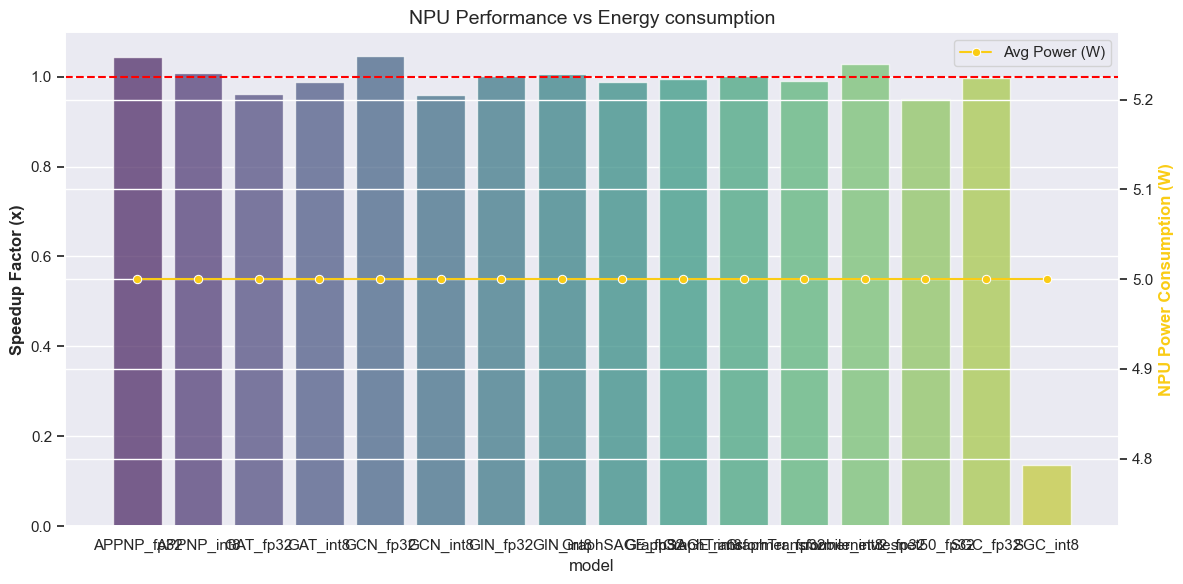

### 📍 ROOFLINE_MODEL.PNG

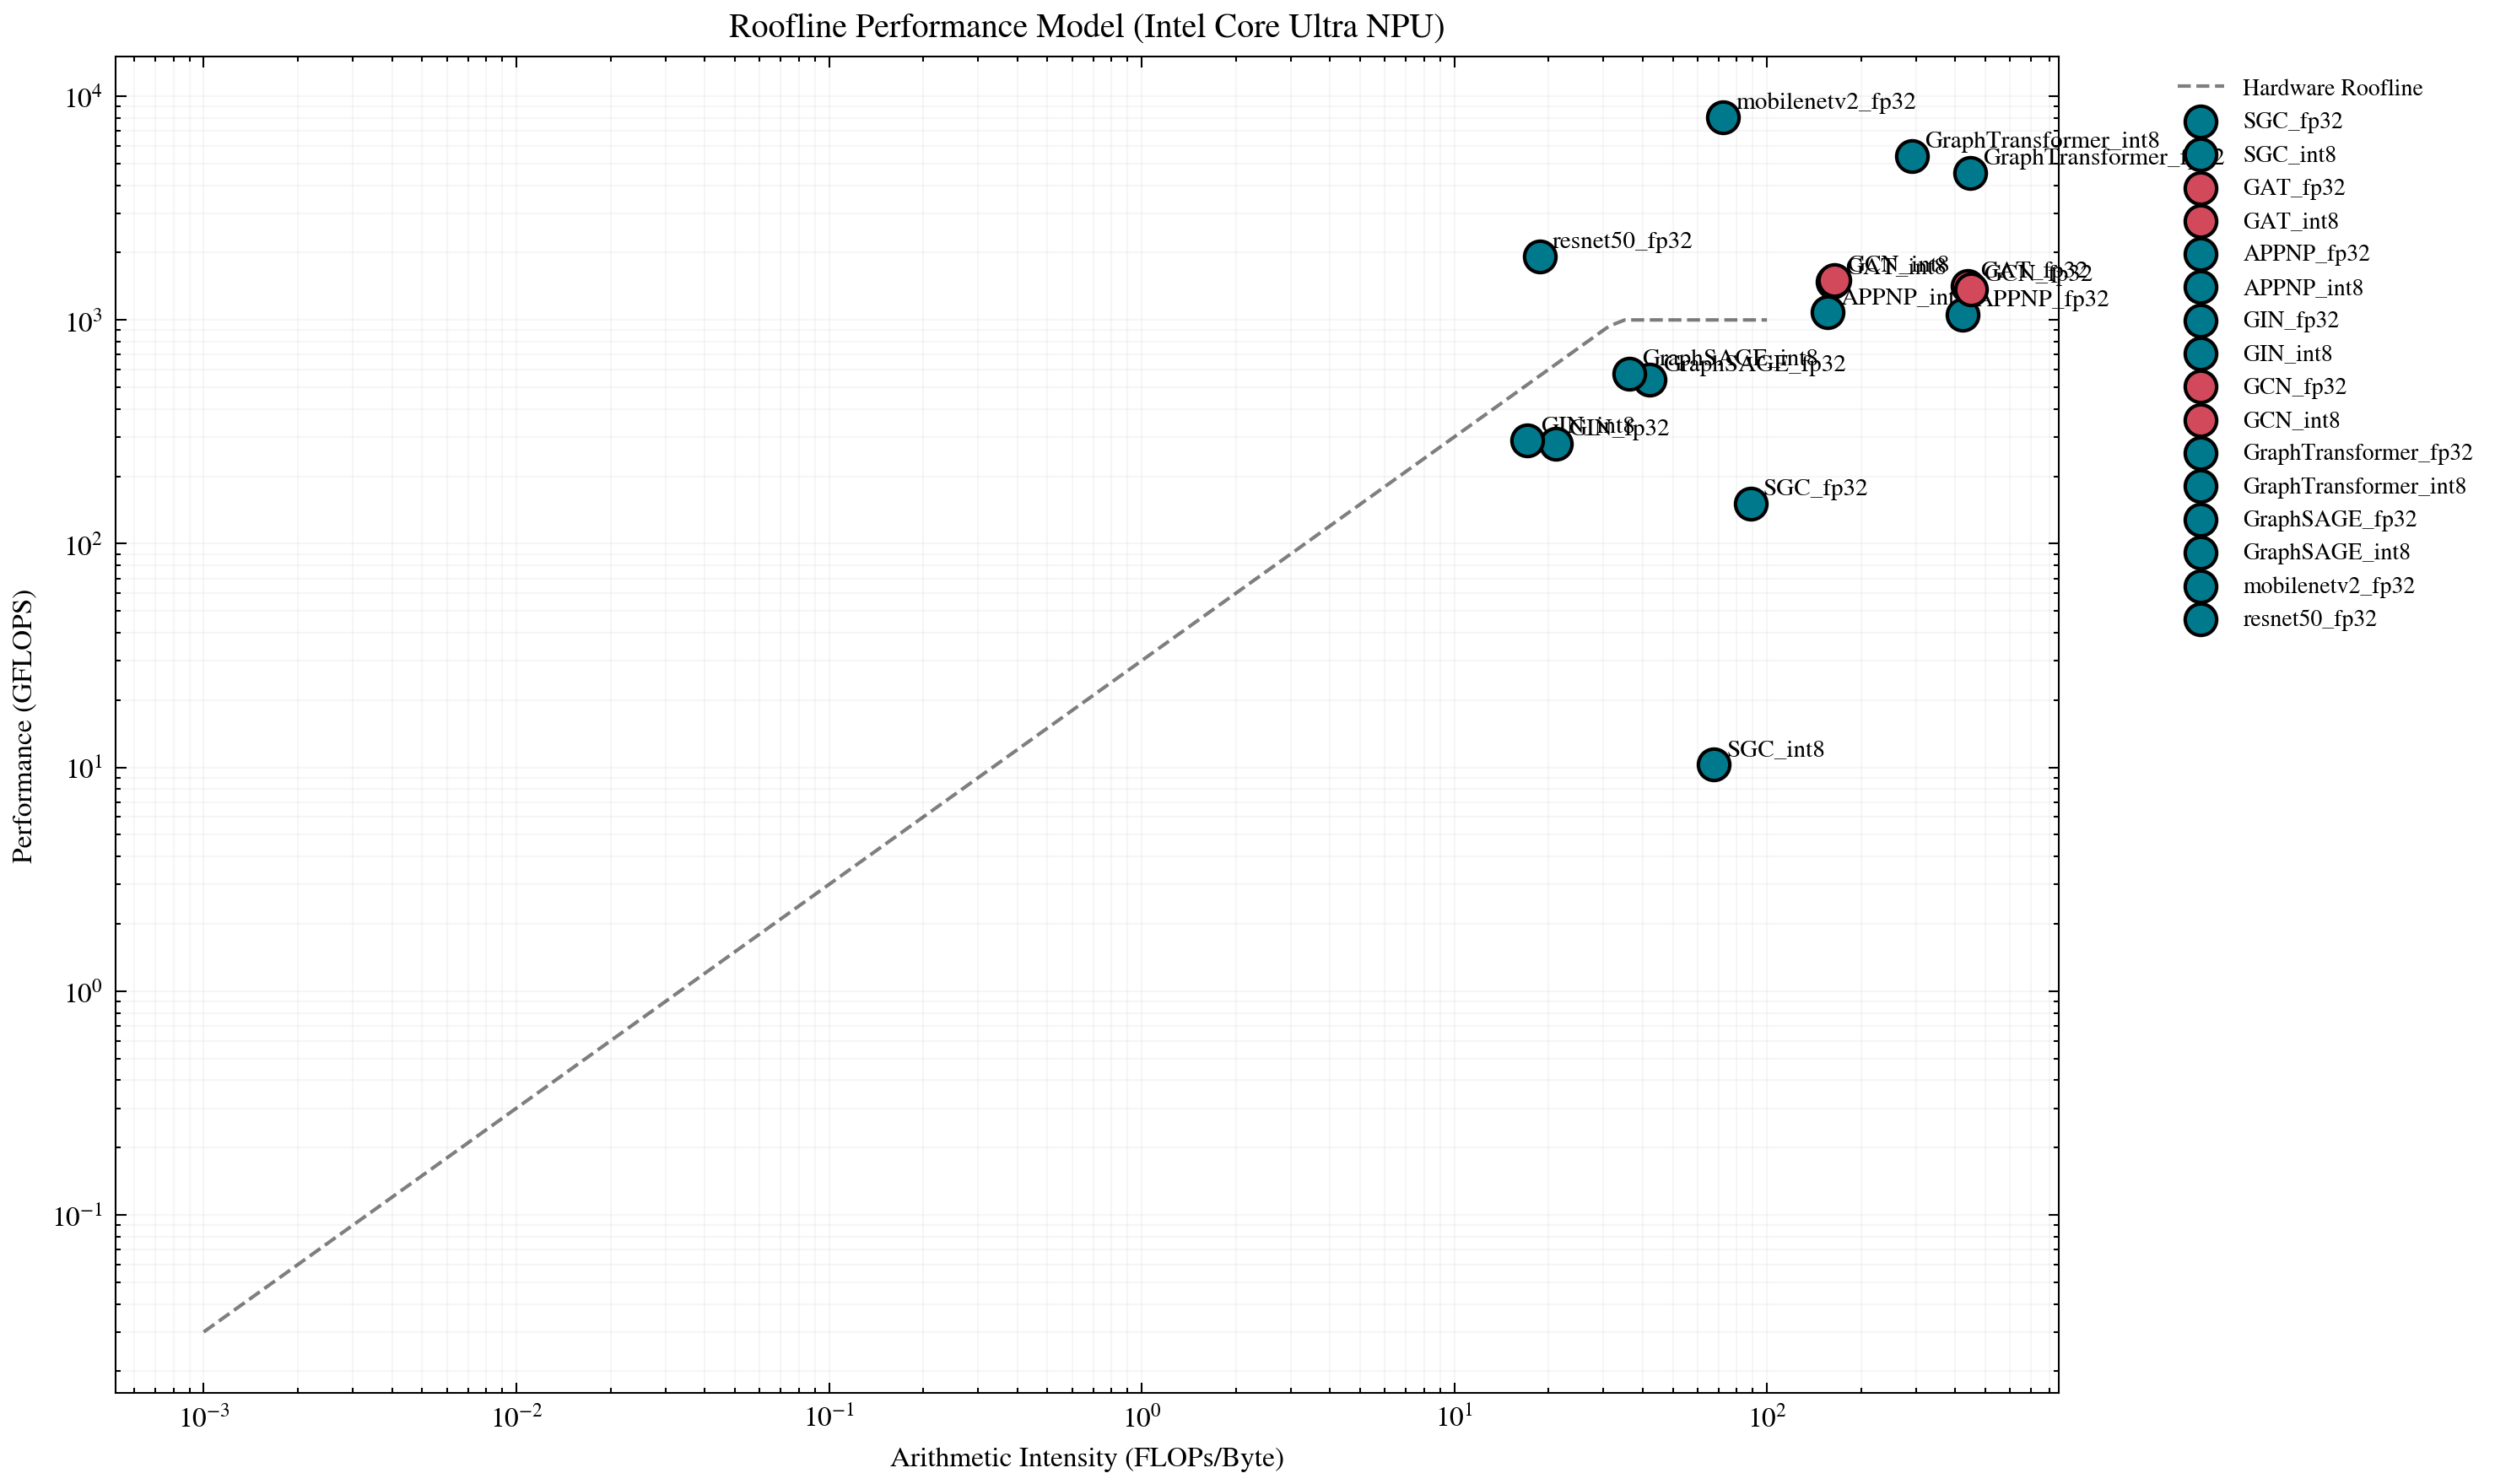

### 📍 LATENCY_STACKED_100PCT.PNG

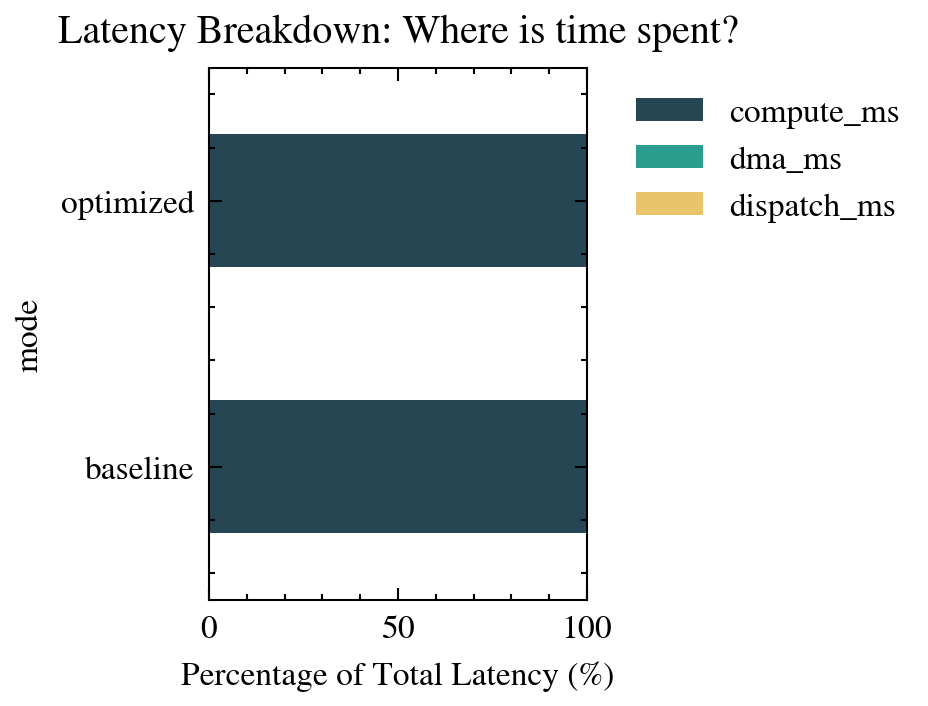

In [ ]:
if Path(MATRIX_FILE).exists():
    df = pd.read_csv(MATRIX_FILE)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df, x="model", y="speedup", hue="model", palette="viridis", legend=False, ax=ax1, alpha=0.7)
    ax1.set_ylabel("Speedup Factor (x)", fontweight='bold')
    ax1.axhline(1.0, color="red", ls="--")
    
    if "avg_npu_power_w" in df.columns:
        ax2 = ax1.twinx()
        sns.lineplot(data=df, x="model", y="avg_npu_power_w", color="#facc15", marker="o", ax=ax2, label="Avg Power (W)")
        ax2.set_ylabel("NPU Power Consumption (W)", color="#facc15", fontweight='bold')
    
    plt.title("NPU Performance vs Energy consumption", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Artifacts
    for img in ["roofline_model.png", "latency_stacked_100pct.png"]:
        if (RESULTS_DIR / img).exists():
            display(Markdown(f"### 📍 {img.upper()}"))
            display(Image(filename=str(RESULTS_DIR / img), width=850))
else:
    print("❌ No data found.")
